# Partial PsyAttention replication: BigFive Essays with multiple seeds and overfitting monitoring

This notebook is a rewritten version of the BERT-only baseline for the first stage of the partial PsyAttention replication.

It does the following:

1. loads the `jingjietan/essays-big5` dataset from Hugging Face;
2. normalizes the Big Five labels;
3. creates a fixed 70/20/10 split;
4. runs majority-class and TF-IDF + Logistic Regression baselines;
5. fine-tunes `bert-base-uncased` by trait and across multiple seeds;
6. uses `eval_loss` to choose the best checkpoint;
7. enables `EarlyStoppingCallback`;
8. saves per-epoch logs to diagnose overfitting;
9. consolidates results by seed, by trait, and overall.

The default configuration is `MODE = "multi_seed_5"`, which runs 5 epochs for the seeds `[13, 42, 100]`.


## 0. Installation

Run this cell only if your environment does not already have the dependencies installed.


In [1]:
# Uncomment if needed.
# %pip install -q datasets transformers accelerate evaluate scikit-learn pandas numpy torch tqdm matplotlib

## 1. Imports and configuration

Useful modes:

- `debug`: quick test with a small sample and one seed.
- `multi_seed_5`: currently recommended configuration, full dataset, 5 epochs, multiple seeds.
- `multi_seed_10`: up to 10 epochs with early stopping.
- `paper_like`: up to 50 epochs with early stopping, only after validating the smaller runs.


In [2]:
import os
import json
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset, concatenate_datasets, DatasetDict
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

# -----------------------------
# Main configuration
# -----------------------------

DATASET_NAME = "jingjietan/essays-big5"
MODEL_NAME = "bert-base-uncased"

# Modes:
# "debug"          -> quick test
# "single_seed_5"  -> full dataset, 5 epochs, main SEED only
# "multi_seed_5"   -> full dataset, 5 epochs, multiple seeds
# "multi_seed_10"  -> full dataset, up to 10 epochs, multiple seeds, early stopping
# "paper_like"     -> full dataset, up to 50 epochs, multiple seeds, early stopping
MODE = "multi_seed_5"

# Fixed split to keep the same data partition in every run.
SPLIT_SEED = 42

# Main seed used in single/debug mode.
SEED = 42

OUTPUT_DIR = Path("./outputs_essays_big5_hf_multiseed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# In Hugging Face, max_length includes [CLS] and [SEP].
# 512 is approximately 510 actual text tokens.
MAX_LENGTH = 512

RUN_TRAITS = ["OPN", "CON", "EXT", "AGR", "NEU"]

# -----------------------------
# Mode-specific configuration
# -----------------------------

if MODE == "debug":
    NUM_EPOCHS = 1
    TRAIN_BATCH_SIZE = 4
    EVAL_BATCH_SIZE = 8
    TRAIN_SEEDS = [SEED]

    MAX_TRAIN_SAMPLES = 200
    MAX_VALID_SAMPLES = 100
    MAX_TEST_SAMPLES = 100

elif MODE == "single_seed_5":
    NUM_EPOCHS = 5
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 16
    TRAIN_SEEDS = [SEED]

    MAX_TRAIN_SAMPLES = None
    MAX_VALID_SAMPLES = None
    MAX_TEST_SAMPLES = None

elif MODE == "multi_seed_5":
    NUM_EPOCHS = 5
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 16
    TRAIN_SEEDS = [13, 42, 100]

    MAX_TRAIN_SAMPLES = None
    MAX_VALID_SAMPLES = None
    MAX_TEST_SAMPLES = None

elif MODE == "multi_seed_10":
    NUM_EPOCHS = 10
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 16
    TRAIN_SEEDS = [13, 42, 100]

    MAX_TRAIN_SAMPLES = None
    MAX_VALID_SAMPLES = None
    MAX_TEST_SAMPLES = None

elif MODE == "paper_like":
    NUM_EPOCHS = 50
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 16
    TRAIN_SEEDS = [13, 42, 100]

    MAX_TRAIN_SAMPLES = None
    MAX_VALID_SAMPLES = None
    MAX_TEST_SAMPLES = None

else:
    raise ValueError(f"Invalid MODE: {MODE}")

# -----------------------------
# Main hyperparameters
# -----------------------------

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# -----------------------------
# Overfitting monitoring
# -----------------------------

# Early stopping uses eval_loss because it is more sensitive than accuracy on a small dataset.
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_THRESHOLD = 0.0

# Post-training diagnostic: if the last eval_loss is 5% worse than the best eval_loss,
# we mark it as possible overfitting.
OVERFIT_RELATIVE_LOSS_GAP = 0.05

# Also evaluate the final model on the training set to calculate the train/validation gap.
# This adds a bit of runtime, but it helps the diagnostic a lot.
EVALUATE_TRAIN_AFTER_FIT = True

# -----------------------------
# Reproducibility and performance
# -----------------------------

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def set_all_seeds(seed: int):
    set_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)

if torch.cuda.is_available():
    # Speeds up training on modern GPUs, especially Ampere/Ada/Hopper.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Mode:", MODE)
print("Dataset:", DATASET_NAME)
print("Model:", MODEL_NAME)
print("Split seed:", SPLIT_SEED)
print("Train seeds:", TRAIN_SEEDS)
print("Maximum epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Max length:", MAX_LENGTH)
print("Batch train:", TRAIN_BATCH_SIZE)
print("Batch eval:", EVAL_BATCH_SIZE)
print("Run traits:", RUN_TRAITS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

Mode: multi_seed_5
Dataset: jingjietan/essays-big5
Model: bert-base-uncased
Split seed: 42
Train seeds: [13, 42, 100]
Maximum epochs: 5
Learning rate: 2e-05
Max length: 512
Batch train: 8
Batch eval: 16
Run traits: ['OPN', 'CON', 'EXT', 'AGR', 'NEU']
Early stopping patience: 2
GPU available: True
GPU: NVIDIA A100-SXM4-40GB
Total GPU memory GB: 42.41


## 2. Load the dataset from Hugging Face

In [3]:
raw_ds = load_dataset(DATASET_NAME)

print(raw_ds)
print("Available splits:", list(raw_ds.keys()))

# Some Hugging Face datasets only come with a "train" split.
# To control the 70/20/10 split, we concatenate all original splits before creating our own.
if len(raw_ds.keys()) == 1:
    all_ds = raw_ds[list(raw_ds.keys())[0]]
else:
    all_ds = concatenate_datasets([raw_ds[split] for split in raw_ds.keys()])

# Keep a stable ID for the original row so the splits can be saved.
if "row_id" not in all_ds.column_names:
    all_ds = all_ds.add_column("row_id", list(range(len(all_ds))))

print("Total examples:", len(all_ds))
print("Columns:", all_ds.column_names)
print(all_ds[0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/795k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/953k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1578 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/395 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/494 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 1578
    })
    validation: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 395
    })
    test: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 494
    })
})
Available splits: ['train', 'validation', 'test']
Total examples: 2467
Columns: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__', 'row_id']
{'O': '1', 'C': '0', 'E': '0', 'A': '1', 'N': '1', 'ptype': '19', 'text': "it is wednesday. I can't wait until friday because I am going home to see brandon. I miss him so much. I can't wait to see him. two more days. this has been a very long two weeks. time passes very slowly here. I have a lot of free time on my hands when I am not in class. class. psychology class. psychology is fun so far. it really interests me, and

## 3. Detect the text column and label columns

In [4]:
def find_first_existing_column(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


columns = all_ds.column_names

TEXT_COL = find_first_existing_column(
    columns,
    ["text", "TEXT", "essay", "Essay", "content", "document"],
)

if TEXT_COL is None:
    raise ValueError(
        f"Could not detect the text column. Available columns: {columns}"
    )

# Map canonical trait names to possible dataset column names.
LABEL_CANDIDATES = {
    "OPN": ["O", "cOPN", "OPN", "opn", "openness", "Openness", "OPENNESS"],
    "CON": ["C", "cCON", "CON", "con", "conscientiousness", "Conscientiousness", "CONSCIENTIOUSNESS"],
    "EXT": ["E", "cEXT", "EXT", "ext", "extraversion", "Extraversion", "EXTRAVERSION"],
    "AGR": ["A", "cAGR", "AGR", "agr", "agreeableness", "Agreeableness", "AGREEABLENESS"],
    "NEU": ["N", "cNEU", "NEU", "neu", "neuroticism", "Neuroticism", "NEUROTICISM"],
}

LABEL_COLS = {}
for trait, candidates in LABEL_CANDIDATES.items():
    col = find_first_existing_column(columns, candidates)
    if col is not None:
        LABEL_COLS[trait] = col

if len(LABEL_COLS) != 5:
    raise ValueError(
        "Could not detect all five Big Five columns.\n"
        f"Detected: {LABEL_COLS}\n"
        f"Available columns: {columns}"
    )

# Respect RUN_TRAITS in case you want to run only some traits.
LABEL_COLS = {trait: LABEL_COLS[trait] for trait in RUN_TRAITS}

print("Text column:", TEXT_COL)
print("Label columns:", LABEL_COLS)

Text column: text
Label columns: {'OPN': 'O', 'CON': 'C', 'EXT': 'E', 'AGR': 'A', 'NEU': 'N'}


## 4. Normalize binary labels and remove invalid examples

In [5]:
def normalize_binary_label(value):
    if value is None:
        return None

    if isinstance(value, (bool, np.bool_)):
        return int(value)

    if isinstance(value, (int, np.integer)):
        if value in [0, 1]:
            return int(value)
        raise ValueError(f"Unexpected integer label: {value}")

    if isinstance(value, (float, np.floating)):
        if np.isnan(value):
            return None
        if value in [0.0, 1.0]:
            return int(value)
        raise ValueError(f"Unexpected float label: {value}")

    if isinstance(value, str):
        v = value.strip().lower()
        positives = {"1", "1.0", "true", "t", "yes", "y", "positive", "pos", "high"}
        negatives = {"0", "0.0", "false", "f", "no", "n", "negative", "neg", "low"}
        if v in positives:
            return 1
        if v in negatives:
            return 0
        raise ValueError(f"Unexpected string label: {value!r}")

    raise TypeError(f"Unexpected label type: {type(value)} | value={value!r}")


def normalize_example(example):
    for trait, col in LABEL_COLS.items():
        example[col] = normalize_binary_label(example[col])
    return example


all_ds = all_ds.map(normalize_example)


def is_valid_example(example):
    if example[TEXT_COL] is None or str(example[TEXT_COL]).strip() == "":
        return False
    for col in LABEL_COLS.values():
        if example[col] is None:
            return False
    return True


all_ds = all_ds.filter(is_valid_example)

print("Total after cleaning:", len(all_ds))

label_summary = {}
for trait, col in LABEL_COLS.items():
    values = pd.Series(all_ds[col])
    label_summary[trait] = values.value_counts().sort_index().to_dict()

pd.DataFrame(label_summary).T.rename(columns={0: "class_0", 1: "class_1"})

Map:   0%|          | 0/2467 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2467 [00:00<?, ? examples/s]

Total after cleaning: 2467


,class_0,class_1
OPN,1196,1271
CON,1214,1253
EXT,1191,1276
AGR,1157,1310
NEU,1234,1233


## 5. Create a fixed 70/20/10 split

The split is fixed by `SPLIT_SEED`. The multiple seeds only vary BERT initialization/training, not the data split.


In [6]:
train_test = all_ds.train_test_split(
    test_size=0.30,
    seed=SPLIT_SEED,
    shuffle=True,
)

valid_test = train_test["test"].train_test_split(
    test_size=1 / 3,  # 1/3 of 30% = 10% overall
    seed=SPLIT_SEED,
    shuffle=True,
)

ds = DatasetDict({
    "train": train_test["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"],
})

print(ds)
print("Proportions:")
print({
    split: round(len(ds[split]) / len(all_ds), 3)
    for split in ds.keys()
})

split_ids = {
    split: list(ds[split]["row_id"])
    for split in ds.keys()
}

split_path = OUTPUT_DIR / f"split_row_ids_seed_{SPLIT_SEED}.json"
with open(split_path, "w", encoding="utf-8") as f:
    json.dump(split_ids, f, ensure_ascii=False, indent=2)

print("Split IDs saved to:", split_path)

DatasetDict({
    train: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__', 'row_id'],
        num_rows: 1726
    })
    validation: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__', 'row_id'],
        num_rows: 494
    })
    test: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__', 'row_id'],
        num_rows: 247
    })
})
Proportions:
{'train': 0.7, 'validation': 0.2, 'test': 0.1}
Split IDs saved to: outputs_essays_big5_hf_multiseed/split_row_ids_seed_42.json


## 6. Check label balance by split

In [7]:
balance_rows = []

for split_name in ["train", "validation", "test"]:
    split_df = ds[split_name].to_pandas()
    for trait, col in LABEL_COLS.items():
        counts = split_df[col].value_counts(normalize=True).sort_index().to_dict()
        balance_rows.append({
            "split": split_name,
            "trait": trait,
            "label_col": col,
            "class_0_share": counts.get(0, 0.0),
            "class_1_share": counts.get(1, 0.0),
            "n": len(split_df),
        })

balance_df = pd.DataFrame(balance_rows)
display(balance_df)
balance_df.to_csv(OUTPUT_DIR / "label_balance_by_split.csv", index=False)

,split,trait,label_col,class_0_share,class_1_share,n
0,train,OPN,O,0.492468,0.507532,1726
1,train,CON,C,0.501159,0.498841,1726
2,train,EXT,E,0.497103,0.502897,1726
3,train,AGR,A,0.478563,0.521437,1726
4,train,NEU,N,0.496524,0.503476,1726
5,validation,OPN,O,0.491903,0.508097,494
6,validation,CON,C,0.475709,0.524291,494
7,validation,EXT,E,0.463563,0.536437,494
8,validation,AGR,A,0.449393,0.550607,494
9,validation,NEU,N,0.524291,0.475709,494


## 7. Baseline 1: majority class

In [8]:
majority_results = []

for trait, label_col in LABEL_COLS.items():
    clf = DummyClassifier(strategy="most_frequent")

    y_train = np.array(ds["train"][label_col])
    y_test = np.array(ds["test"][label_col])

    clf.fit(np.zeros((len(y_train), 1)), y_train)
    preds = clf.predict(np.zeros((len(y_test), 1)))

    acc = accuracy_score(y_test, preds)
    majority_results.append({
        "model": "majority",
        "trait": trait,
        "label_col": label_col,
        "accuracy": acc,
        "split_seed": SPLIT_SEED,
        "seed": None,
        "mode": "baseline",
    })

majority_df = pd.DataFrame(majority_results)
majority_df

,model,trait,label_col,accuracy,split_seed,seed,mode
0,majority,OPN,O,0.582996,42,None,baseline
1,majority,CON,C,0.461538,42,None,baseline
2,majority,EXT,E,0.578947,42,None,baseline
3,majority,AGR,A,0.558704,42,None,baseline
4,majority,NEU,N,0.522267,42,None,baseline


## 8. Baseline 2: TF-IDF + Logistic Regression

In [9]:
tfidf_results = []

for trait, label_col in LABEL_COLS.items():
    vectorizer = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        lowercase=True,
        min_df=2,
    )

    X_train = vectorizer.fit_transform(ds["train"][TEXT_COL])
    X_test = vectorizer.transform(ds["test"][TEXT_COL])

    y_train = np.array(ds["train"][label_col])
    y_test = np.array(ds["test"][label_col])

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=None,
        random_state=SPLIT_SEED,
    )

    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)
    tfidf_results.append({
        "model": "tfidf_logreg",
        "trait": trait,
        "label_col": label_col,
        "accuracy": acc,
        "split_seed": SPLIT_SEED,
        "seed": None,
        "mode": "baseline",
    })

tfidf_df = pd.DataFrame(tfidf_results)
tfidf_df

,model,trait,label_col,accuracy,split_seed,seed,mode
0,tfidf_logreg,OPN,O,0.578947,42,None,baseline
1,tfidf_logreg,CON,C,0.574899,42,None,baseline
2,tfidf_logreg,EXT,E,0.566802,42,None,baseline
3,tfidf_logreg,AGR,A,0.538462,42,None,baseline
4,tfidf_logreg,NEU,N,0.570850,42,None,baseline


## 9. Prepare BERT

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# Measure how much of the training set would be truncated at MAX_LENGTH.
lengths = tokenizer(
    list(ds["train"][TEXT_COL]),
    add_special_tokens=True,
    truncation=False,
)["input_ids"]

lengths = [len(x) for x in lengths]
print("Mean token length:", np.mean(lengths))
print("Median token length:", np.median(lengths))
print("Share truncated:", np.mean([x > MAX_LENGTH for x in lengths]))



def maybe_select(dataset, max_samples):
    if max_samples is None:
        return dataset
    return dataset.select(range(min(len(dataset), max_samples)))


def tokenize_for_trait(dataset_dict, label_col):
    def tokenize_batch(batch):
        encoded = tokenizer(
            batch[TEXT_COL],
            truncation=True,
            max_length=MAX_LENGTH,
        )
        encoded["labels"] = [int(x) for x in batch[label_col]]
        return encoded

    tokenized = DatasetDict()
    for split in ["train", "validation", "test"]:
        split_ds = dataset_dict[split]
        if split == "train":
            split_ds = maybe_select(split_ds, MAX_TRAIN_SAMPLES)
        elif split == "validation":
            split_ds = maybe_select(split_ds, MAX_VALID_SAMPLES)
        elif split == "test":
            split_ds = maybe_select(split_ds, MAX_TEST_SAMPLES)

        tokenized[split] = split_ds.map(
            tokenize_batch,
            batched=True,
            remove_columns=split_ds.column_names,
        )

    return tokenized


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


# Tokenize once per trait. This avoids repeating the work for each seed.
tokenized_by_trait = {}
for trait, label_col in LABEL_COLS.items():
    print(f"Tokenizing {trait}...")
    tokenized_by_trait[trait] = tokenize_for_trait(ds, label_col)

print("Tokenization complete.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (862 > 512). Running this sequence through the model will result in indexing errors


...

Tokenizing NEU...


Map:   0%|          | 0/1726 [00:00<?, ? examples/s]

Map:   0%|          | 0/494 [00:00<?, ? examples/s]

Map:   0%|          | 0/247 [00:00<?, ? examples/s]

Tokenization complete.


## 10. Overfitting diagnostic function

In [11]:
def diagnose_overfitting(log_history, relative_loss_gap=0.05):
    # Analyze the Trainer history and return a simple overfitting diagnostic.
    log_df = pd.DataFrame(log_history)

    if "eval_loss" not in log_df.columns:
        return {
            "best_epoch": None,
            "last_epoch": None,
            "best_eval_loss": None,
            "last_eval_loss": None,
            "best_eval_accuracy": None,
            "last_eval_accuracy": None,
            "possible_overfitting": None,
            "reason": "No eval_loss column in log_history.",
        }

    eval_df = log_df[log_df["eval_loss"].notna()].copy()

    if eval_df.empty:
        return {
            "best_epoch": None,
            "last_epoch": None,
            "best_eval_loss": None,
            "last_eval_loss": None,
            "best_eval_accuracy": None,
            "last_eval_accuracy": None,
            "possible_overfitting": None,
            "reason": "No eval_loss records in log_history.",
        }

    best_loss_idx = eval_df["eval_loss"].idxmin()
    best_row = eval_df.loc[best_loss_idx]
    last_row = eval_df.iloc[-1]

    best_eval_loss = float(best_row["eval_loss"])
    last_eval_loss = float(last_row["eval_loss"])

    best_epoch = float(best_row["epoch"]) if "epoch" in best_row and pd.notna(best_row["epoch"]) else None
    last_epoch = float(last_row["epoch"]) if "epoch" in last_row and pd.notna(last_row["epoch"]) else None

    best_eval_accuracy = None
    last_eval_accuracy = None
    if "eval_accuracy" in eval_df.columns:
        best_eval_accuracy = float(best_row["eval_accuracy"])
        last_eval_accuracy = float(last_row["eval_accuracy"])

    loss_worse_than_best = last_eval_loss > best_eval_loss * (1 + relative_loss_gap)
    best_before_last = best_epoch is not None and last_epoch is not None and best_epoch < last_epoch
    possible_overfitting = bool(loss_worse_than_best and best_before_last)

    if possible_overfitting:
        reason = (
            f"Possible overfitting: the best eval_loss occurred at epoch {best_epoch:.1f}, "
            f"but the last eval_loss was higher at epoch {last_epoch:.1f}."
        )
    else:
        reason = "No strong sign of overfitting by the eval_loss criterion."

    return {
        "best_epoch": best_epoch,
        "last_epoch": last_epoch,
        "best_eval_loss": best_eval_loss,
        "last_eval_loss": last_eval_loss,
        "best_eval_accuracy": best_eval_accuracy,
        "last_eval_accuracy": last_eval_accuracy,
        "possible_overfitting": possible_overfitting,
        "reason": reason,
    }


def safe_get(metrics, key):
    value = metrics.get(key)
    if value is None:
        return None
    try:
        return float(value)
    except Exception:
        return value

## 11. Train BERT-base by trait and by seed

This is the slowest block. It runs:

`n_seeds × n_traits` training jobs.

With the current default: `3 seeds × 5 traits = 15 training jobs`.


In [12]:
bert_results = []
bert_reports = {}

for train_seed in TRAIN_SEEDS:
    set_all_seeds(train_seed)

    print("\n" + "#" * 100)
    print(f"STARTING SEED {train_seed}")
    print("#" * 100)

    for trait, label_col in LABEL_COLS.items():
        print("\n" + "=" * 100)
        print(f"Training BERT for {trait} | column={label_col} | seed={train_seed}")
        print("=" * 100)

        trait_output_dir = OUTPUT_DIR / MODE / f"seed_{train_seed}" / f"bert_{trait.lower()}"
        trait_output_dir.mkdir(parents=True, exist_ok=True)

        tokenized = tokenized_by_trait[trait]

        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2,
        )

        training_args = TrainingArguments(
            output_dir=str(trait_output_dir),

            # Evaluate, save, and log at each epoch.
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",

            learning_rate=LEARNING_RATE,
            per_device_train_batch_size=TRAIN_BATCH_SIZE,
            per_device_eval_batch_size=EVAL_BATCH_SIZE,
            num_train_epochs=NUM_EPOCHS,
            weight_decay=WEIGHT_DECAY,

            # To monitor overfitting, choose the checkpoint by eval_loss.
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,

            save_total_limit=2,
            seed=train_seed,
            data_seed=SPLIT_SEED,
            report_to="none",
            fp16=torch.cuda.is_available(),
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized["train"],
            eval_dataset=tokenized["validation"],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[
                EarlyStoppingCallback(
                    early_stopping_patience=EARLY_STOPPING_PATIENCE,
                    early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
                )
            ],
        )

        train_output = trainer.train()

        # Save the detailed history for later analysis.
        log_df = pd.DataFrame(trainer.state.log_history)
        log_df["trait"] = trait
        log_df["label_col"] = label_col
        log_df["seed"] = train_seed
        log_df["split_seed"] = SPLIT_SEED
        log_df["mode"] = MODE
        log_df["epochs_configured"] = NUM_EPOCHS

        log_path = trait_output_dir / "trainer_log_history.csv"
        log_df.to_csv(log_path, index=False)

        overfit_info = diagnose_overfitting(
            trainer.state.log_history,
            relative_loss_gap=OVERFIT_RELATIVE_LOSS_GAP,
        )

        print("\nOverfitting diagnostic:")
        print(json.dumps(overfit_info, indent=2, ensure_ascii=False))

        # Optional training-set evaluation using the best checkpoint loaded at the end.
        if EVALUATE_TRAIN_AFTER_FIT:
            train_metrics = trainer.evaluate(tokenized["train"], metric_key_prefix="train")
        else:
            train_metrics = {}

        validation_metrics = trainer.evaluate(tokenized["validation"], metric_key_prefix="validation")

        pred_output = trainer.predict(tokenized["test"])
        test_logits = pred_output.predictions
        test_labels = pred_output.label_ids
        test_preds = np.argmax(test_logits, axis=-1)

        test_acc = accuracy_score(test_labels, test_preds)
        report = classification_report(
            test_labels,
            test_preds,
            output_dict=True,
            zero_division=0,
        )

        epochs_completed = float(trainer.state.epoch) if trainer.state.epoch is not None else None
        stopped_early = bool(epochs_completed is not None and epochs_completed < NUM_EPOCHS)

        run_key = f"seed_{train_seed}_{trait}"
        bert_reports[run_key] = report

        bert_results.append({
            "model": "bert_base_finetune",
            "trait": trait,
            "label_col": label_col,
            "accuracy": test_acc,
            "mode": MODE,
            "split_seed": SPLIT_SEED,
            "seed": train_seed,
            "epochs_configured": NUM_EPOCHS,
            "epochs_completed": epochs_completed,
            "stopped_early": stopped_early,
            "max_train_samples": MAX_TRAIN_SAMPLES,

            "train_loss_best_model": safe_get(train_metrics, "train_loss"),
            "train_accuracy_best_model": safe_get(train_metrics, "train_accuracy"),
            "validation_loss_best_model": safe_get(validation_metrics, "validation_loss"),
            "validation_accuracy_best_model": safe_get(validation_metrics, "validation_accuracy"),

            "best_epoch": overfit_info["best_epoch"],
            "last_epoch": overfit_info["last_epoch"],
            "best_eval_loss": overfit_info["best_eval_loss"],
            "last_eval_loss": overfit_info["last_eval_loss"],
            "best_eval_accuracy": overfit_info["best_eval_accuracy"],
            "last_eval_accuracy": overfit_info["last_eval_accuracy"],
            "possible_overfitting": overfit_info["possible_overfitting"],
            "overfit_reason": overfit_info["reason"],

            "train_runtime": safe_get(train_output.metrics, "train_runtime"),
            "train_samples_per_second": safe_get(train_output.metrics, "train_samples_per_second"),
            "trainer_log_path": str(log_path),
        })

        trainer.save_model(str(trait_output_dir / "best_model"))

        # Free memory before the next trait/seed.
        del trainer
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

bert_df = pd.DataFrame(bert_results)
bert_df


####################################################################################################
STARTING SEED 13
####################################################################################################

Training BERT for OPN | column=O | seed=13


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.687906,0.703971,0.528340
2,0.644238,0.664288,0.633603
3,0.592708,0.653038,0.645749
4,0.476746,0.708767,0.635628
5,0.366697,0.761810,0.643725


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Overfitting diagnostic:
{
  "best_epoch": 1.0,
  "last_epoch": 3.0,
  "best_eval_loss": 0.6916137933731079,
  "last_eval_loss": 0.7235579490661621,
  "best_eval_accuracy": 0.548582995951417,
  "last_eval_accuracy": 0.5587044534412956,
  "possible_overfitting": false,
  "reason": "No strong sign of overfitting by the eval_loss criterion."
}


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,model,trait,label_col,accuracy,mode,split_seed,seed,epochs_configured,epochs_completed,stopped_early,...,last_epoch,best_eval_loss,last_eval_loss,best_eval_accuracy,last_eval_accuracy,possible_overfitting,overfit_reason,train_runtime,train_samples_per_second,trainer_log_path
0,bert_base_finetune,OPN,O,0.599190,multi_seed_5,42,13,5,5.0,False,...,5.0,0.653038,0.761810,0.645749,0.643725,True,Possible overfitting: the best eval_loss occur...,74.8966,115.225,outputs_essays_big5_hf_multiseed/multi_seed_5/...
1,bert_base_finetune,CON,C,0.554656,multi_seed_5,42,13,5,3.0,True,...,3.0,0.691011,0.747999,0.532389,0.536437,True,Possible overfitting: the best eval_loss occur...,44.2672,194.952,outputs_essays_big5_hf_multiseed/multi_seed_5/...
2,bert_base_finetune,EXT,E,0.554656,multi_seed_5,42,13,5,4.0,True,...,4.0,0.683443,0.904115,0.572874,0.580972,True,Possible overfitting: the best eval_loss occur...,59.3109,145.505,outputs_essays_big5_hf_multiseed/multi_seed_5/...
3,bert_base_finetune,AGR,A,0.582996,multi_seed_5,42,13,5,5.0,False,...,5.0,0.682464,0.682464,0.572874,0.572874,False,No strong sign of overfitting by the eval_loss...,74.7114,115.511,outputs_essays_big5_hf_multiseed/multi_seed_5/...
4,bert_base_finetune,NEU,N,0.518219,multi_seed_5,42,13,5,3.0,True,...,3.0,0.692762,0.737435,0.483806,0.536437,True,Possible overfitting: the best eval_loss occur...,43.3180,199.224,outputs_essays_big5_hf_multiseed/multi_seed_5/...
5,bert_base_finetune,OPN,O,0.607287,multi_seed_5,42,42,5,4.0,True,...,4.0,0.643466,0.654048,0.637652,0.651822,False,No strong sign of overfitting by the eval_loss...,57.6586,149.674,outputs_essays_big5_hf_multiseed/multi_seed_5/...
6,bert_base_finetune,CON,C,0.574899,multi_seed_5,42,42,5,4.0,True,...,4.0,0.689842,0.820462,0.544534,0.536437,True,Possible overfitting: the best eval_loss occur...,59.1529,145.893,outputs_essays_big5_hf_multiseed/multi_seed_5/...
7,bert_base_finetune,EXT,E,0.538462,multi_seed_5,42,42,5,4.0,True,...,4.0,0.692126,0.788825,0.560729,0.522267,True,Possible overfitting: the best eval_loss occur...,58.9845,146.310,outputs_essays_big5_hf_multiseed/multi_seed_5/...
8,bert_base_finetune,AGR,A,0.603239,multi_seed_5,42,42,5,5.0,False,...,5.0,0.683897,0.850289,0.558704,0.570850,True,Possible overfitting: the best eval_loss occur...,72.6961,118.713,outputs_essays_big5_hf_multiseed/multi_seed_5/...
9,bert_base_finetune,NEU,N,0.526316,multi_seed_5,42,42,5,3.0,True,...,3.0,0.687715,0.739569,0.546559,0.524291,True,Possible overfitting: the best eval_loss occur...,44.2539,195.011,outputs_essays_big5_hf_multiseed/multi_seed_5/...


## 12. Consolidate results

In [13]:
baseline_df = pd.concat([majority_df, tfidf_df], ignore_index=True)
all_results = pd.concat([baseline_df, bert_df], ignore_index=True, sort=False)

# Simple mean by model. For BERT, this mixes seeds and traits.
model_summary = (
    all_results
    .groupby("model", as_index=False)
    .agg(
        avg_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        n=("accuracy", "count"),
    )
    .sort_values("avg_accuracy", ascending=False)
)

# BERT mean by seed, aggregating the five traits.
bert_seed_summary = (
    bert_df
    .groupby("seed", as_index=False)
    .agg(
        avg_accuracy=("accuracy", "mean"),
        std_trait_accuracy=("accuracy", "std"),
        min_trait_accuracy=("accuracy", "min"),
        max_trait_accuracy=("accuracy", "max"),
        overfit_flags=("possible_overfitting", "sum"),
        stopped_early_count=("stopped_early", "sum"),
        mean_epochs_completed=("epochs_completed", "mean"),
    )
    .sort_values("avg_accuracy", ascending=False)
)

# Mean by trait across seeds.
bert_trait_summary = (
    bert_df
    .groupby("trait", as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        min_accuracy=("accuracy", "min"),
        max_accuracy=("accuracy", "max"),
        overfit_flags=("possible_overfitting", "sum"),
        stopped_early_count=("stopped_early", "sum"),
        mean_best_epoch=("best_epoch", "mean"),
    )
    .sort_values("mean_accuracy", ascending=False)
)

bert_overall = pd.DataFrame([
    {
        "model": "bert_base_finetune_seed_mean",
        "mean_of_seed_averages": bert_seed_summary["avg_accuracy"].mean(),
        "std_of_seed_averages": bert_seed_summary["avg_accuracy"].std(),
        "n_seeds": bert_seed_summary["seed"].nunique(),
        "n_runs": len(bert_df),
    }
])

print("All results:")
display(all_results)

print("Summary by model:")
display(model_summary)

print("BERT summary by seed:")
display(bert_seed_summary)

print("BERT summary by trait:")
display(bert_trait_summary)

print("Overall BERT summary:")
display(bert_overall)

# Save the main files.
all_results.to_csv(OUTPUT_DIR / f"results_by_trait_{MODE}.csv", index=False)
model_summary.to_csv(OUTPUT_DIR / f"results_model_summary_{MODE}.csv", index=False)
bert_seed_summary.to_csv(OUTPUT_DIR / f"bert_seed_summary_{MODE}.csv", index=False)
bert_trait_summary.to_csv(OUTPUT_DIR / f"bert_trait_summary_{MODE}.csv", index=False)
bert_overall.to_csv(OUTPUT_DIR / f"bert_overall_summary_{MODE}.csv", index=False)

with open(OUTPUT_DIR / f"bert_classification_reports_{MODE}.json", "w", encoding="utf-8") as f:
    json.dump(bert_reports, f, ensure_ascii=False, indent=2)

print("Results saved to:", OUTPUT_DIR.resolve())

All results:


,model,trait,label_col,accuracy,split_seed,seed,mode,epochs_configured,epochs_completed,stopped_early,...,last_epoch,best_eval_loss,last_eval_loss,best_eval_accuracy,last_eval_accuracy,possible_overfitting,overfit_reason,train_runtime,train_samples_per_second,trainer_log_path
0,majority,OPN,O,0.582996,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,majority,CON,C,0.461538,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,majority,EXT,E,0.578947,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,majority,AGR,A,0.558704,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,majority,NEU,N,0.522267,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,tfidf_logreg,OPN,O,0.578947,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,tfidf_logreg,CON,C,0.574899,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,tfidf_logreg,EXT,E,0.566802,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,tfidf_logreg,AGR,A,0.538462,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,tfidf_logreg,NEU,N,0.570850,42,None,baseline,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Summary by model:


,model,avg_accuracy,std_accuracy,n
2,tfidf_logreg,0.565992,0.016042,5
0,bert_base_finetune,0.562753,0.030219,15
1,majority,0.540891,0.050453,5


BERT summary by seed:


...

BERT summary by trait:


,trait,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,overfit_flags,stopped_early_count,mean_best_epoch
4,OPN,0.595142,0.014597,0.578947,0.607287,2,2,2.333333
0,AGR,0.589744,0.011687,0.582996,0.603239,2,1,3.000000
1,CON,0.556005,0.018256,0.538462,0.574899,3,3,1.333333
2,EXT,0.551957,0.012369,0.538462,0.562753,3,2,2.333333
3,NEU,0.520918,0.004675,0.518219,0.526316,2,3,1.000000


Overall BERT summary:


,model,mean_of_seed_averages,std_of_seed_averages,n_seeds,n_runs
0,bert_base_finetune_seed_mean,0.562753,0.006918,3,15


Results saved to: /content/outputs_essays_big5_hf_multiseed


## 13. Compact table for the report

In [14]:
# Compact table: baselines + BERT mean by seed.
baseline_summary = (
    baseline_df
    .groupby("model", as_index=False)
    .agg(avg_accuracy=("accuracy", "mean"))
)

compact_rows = baseline_summary.to_dict("records")
compact_rows.append({
    "model": "bert_base_finetune_mean_across_seeds",
    "avg_accuracy": float(bert_seed_summary["avg_accuracy"].mean()),
})
compact_rows.append({
    "model": "paper_bert_base_mlp_reference",
    "avg_accuracy": 0.606,
})
compact_rows.append({
    "model": "paper_psyattention_reference",
    "avg_accuracy": 0.6566,
})

compact_summary = pd.DataFrame(compact_rows).sort_values("avg_accuracy", ascending=False)
compact_summary

,model,avg_accuracy
4,paper_psyattention_reference,0.656600
3,paper_bert_base_mlp_reference,0.606000
1,tfidf_logreg,0.565992
2,bert_base_finetune_mean_across_seeds,0.562753
0,majority,0.540891


## 14. Inspect overfitting logs

In [15]:
all_log_files = list((OUTPUT_DIR / MODE).glob("seed_*/bert_*/trainer_log_history.csv"))
print("Log files found:", len(all_log_files))

logs = []
for path in all_log_files:
    temp = pd.read_csv(path)
    temp["file"] = str(path)
    logs.append(temp)

if logs:
    logs_df = pd.concat(logs, ignore_index=True)
    cols_to_show = [
        c for c in [
            "seed", "trait", "epoch", "loss", "eval_loss", "eval_accuracy",
            "learning_rate", "train_loss", "mode"
        ]
        if c in logs_df.columns
    ]
    display(logs_df[cols_to_show].dropna(how="all", subset=[c for c in ["loss", "eval_loss", "eval_accuracy"] if c in logs_df.columns]))
else:
    logs_df = pd.DataFrame()
    print("No logs found yet.")

Log files found: 15


,seed,trait,epoch,loss,eval_loss,eval_accuracy,learning_rate,train_loss,mode
0,13,EXT,1.0,0.699491,NaN,NaN,0.000016,NaN,multi_seed_5
1,13,EXT,1.0,NaN,0.692482,0.508097,NaN,NaN,multi_seed_5
2,13,EXT,2.0,0.691709,NaN,NaN,0.000012,NaN,multi_seed_5
3,13,EXT,2.0,NaN,0.683443,0.572874,NaN,NaN,multi_seed_5
4,13,EXT,3.0,0.624172,NaN,NaN,0.000008,NaN,multi_seed_5
...,...,...,...,...,...,...,...,...,...
125,42,OPN,2.0,NaN,0.643466,0.637652,NaN,NaN,multi_seed_5
126,42,OPN,3.0,0.618268,NaN,NaN,0.000008,NaN,multi_seed_5
127,42,OPN,3.0,NaN,0.660136,0.643725,NaN,NaN,multi_seed_5
128,42,OPN,4.0,0.561405,NaN,NaN,0.000004,NaN,multi_seed_5


## 15. Optional plot: eval_loss by epoch

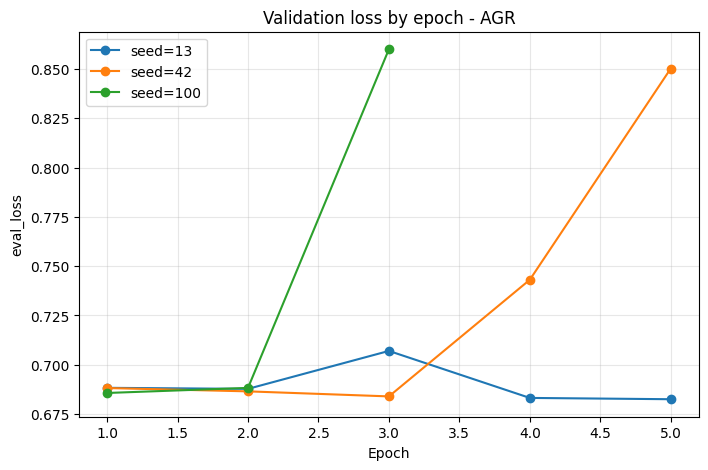

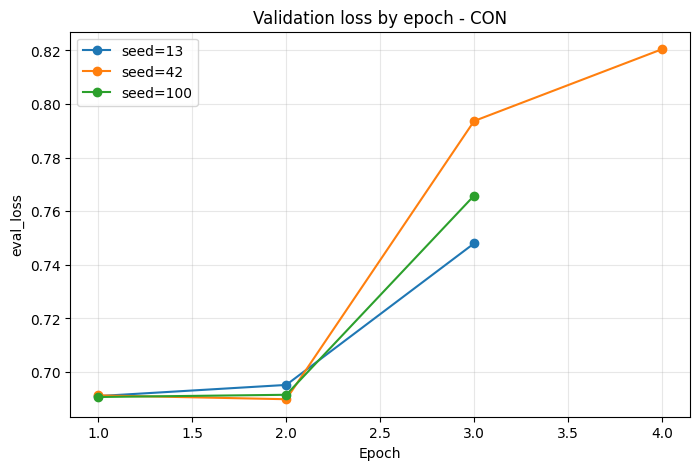

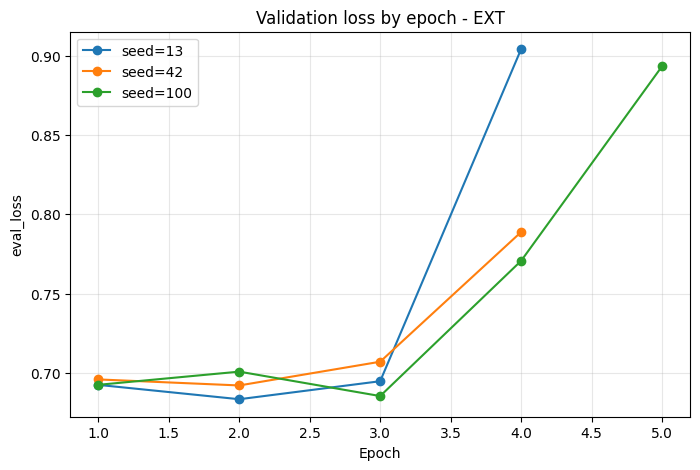

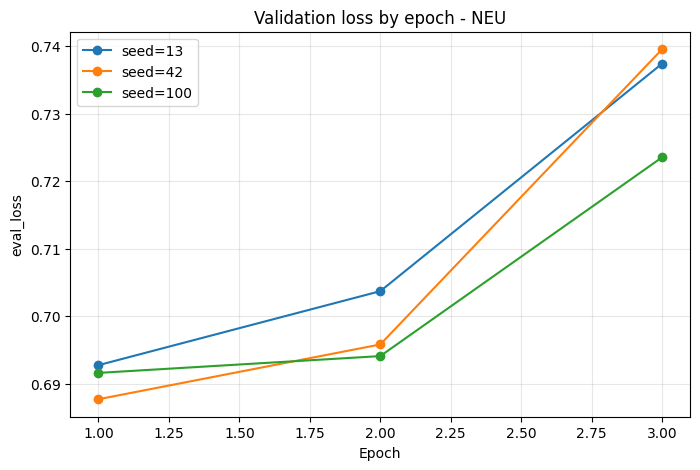

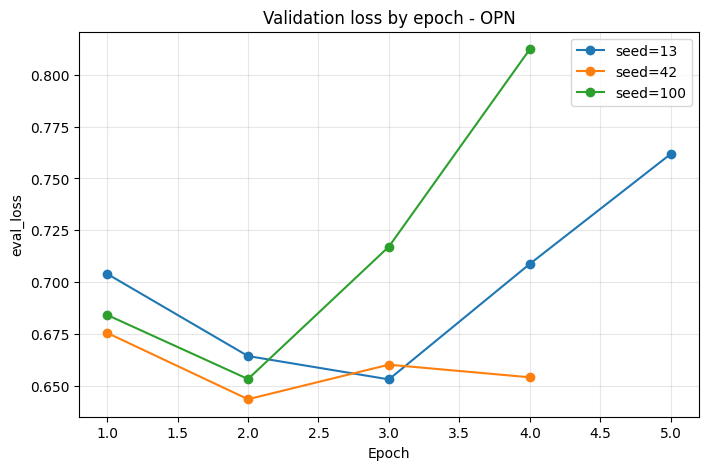

In [16]:
# This plot is optional. It helps visually check whether validation loss starts to rise.
if not logs_df.empty:
    import matplotlib.pyplot as plt

    for trait in sorted(logs_df["trait"].dropna().unique()):
        trait_logs = logs_df[(logs_df["trait"] == trait) & logs_df["eval_loss"].notna()].copy()
        if trait_logs.empty:
            continue

        plt.figure(figsize=(8, 5))
        for seed in sorted(trait_logs["seed"].dropna().unique()):
            seed_logs = trait_logs[trait_logs["seed"] == seed]
            plt.plot(seed_logs["epoch"], seed_logs["eval_loss"], marker="o", label=f"seed={int(seed)}")

        plt.title(f"Validation loss by epoch - {trait}")
        plt.xlabel("Epoch")
        plt.ylabel("eval_loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("Run training before plotting the logs.")

## 16. Expected interpretation

Use these practical rules:

- If `multi_seed_5` stays close to a 0.59 mean, your BERT baseline is healthy.
- If `multi_seed_10` does not improve or often triggers early stopping, 5 epochs is probably better.
- If `possible_overfitting=True` appears for several traits/seeds, it is not worth running `paper_like` yet.
- Small differences between seeds are normal on BigFive Essays because the dataset is small.
- The next step after this notebook is to implement `psychological features + MLP` using SEANCE/TAACO/TAALES.


## 17. Next step: connect psychological features

When you have a CSV with extracted psychological features, use this entry point.

The CSV should contain:

- `row_id`
- one column per psychological feature

This lets you reuse the exact same split from this notebook.


In [17]:
# Optional: use this after extracting psychological features outside this notebook.
PSY_FEATURES_CSV = None  # example: "./features/essays_big5_psyfeatures.csv"

if PSY_FEATURES_CSV is not None:
    psy_df = pd.read_csv(PSY_FEATURES_CSV)
    assert "row_id" in psy_df.columns, "The features CSV must contain the row_id column."

    feature_cols = [c for c in psy_df.columns if c != "row_id"]
    print("Total psychological features:", len(feature_cols))

    train_ids = pd.DataFrame({"row_id": ds["train"]["row_id"]})
    train_features = train_ids.merge(psy_df, on="row_id", how="left")

    print(train_features.shape)
    display(train_features.head())
else:
    print("No psychological-features CSV provided. Skip this cell for now.")

No psychological-features CSV provided. Skip this cell for now.


## 18. Replication checklist

- [x] Run the BERT baseline on the full dataset.
- [x] Save the 70/20/10 split.
- [x] Run multiple seeds.
- [x] Monitor `eval_loss` by epoch.
- [x] Enable early stopping.
- [x] Save logs by trait and seed.
- [ ] Compare `multi_seed_5` vs `multi_seed_10`.
- [ ] Extract SEANCE, TAACO, and TAALES.
- [ ] Perform Pearson-correlation-based feature selection.
- [ ] Implement the `psychological features + MLP` baseline.
- [ ] Implement BERT + psychological-feature fusion.
- [ ] Implement the full PsyAttention model.
